# 🎬 Final Demo — Improved Multimodal Deepfake Detection

This notebook is a cleaner replacement for the final demo stage and is meant to be run directly in Google Colab.

## What is improved
- Uses **actual trained modality models** for inference.
- Does **not depend on `10_fusion_model.ipynb`** during demo/inference.
- Adds **confidence-aware fusion** and a **consensus correction**.
- Lets you **choose a video file to upload** from your computer, or use a Drive path.
- Produces a **report + plots** for demo/viva.


In [2]:
# Cell 1 — Install & imports
!pip install -q torch torchvision librosa opencv-python-headless matplotlib scikit-learn tqdm

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, cv2, json, shutil, urllib.request, warnings, numpy as np, librosa, torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Device:", DEVICE)

Mounted at /content/drive
✅ Device: cpu


In [3]:
# Cell 2 — Paths & config
BASE_DIR = "/content/drive/MyDrive/deepfake-project"

MODEL_DIR  = os.path.join(BASE_DIR, "models")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "final_demo")
TMP_DIR    = "/tmp/deepfake_demo"

FACES_TMP  = os.path.join(TMP_DIR, "faces")
MOUTHS_TMP = os.path.join(TMP_DIR, "mouths")
AUDIO_TMP  = os.path.join(TMP_DIR, "audio.wav")

for p in [OUTPUT_DIR, TMP_DIR, FACES_TMP, MOUTHS_TMP]:
    os.makedirs(p, exist_ok=True)

IMG_SIZE      = 224
MOUTH_SIZE    = 96
SEQ_LEN       = 10
SR            = 16000
AUDIO_WIN     = 0.2
N_FRAMES_SYNC = 5
EMB_DIM       = 128

MODEL_PATHS = {
    "visual":   os.path.join(MODEL_DIR, "visual_cnn.pth"),
    "temporal": os.path.join(MODEL_DIR, "temporal_lstm.pth"),
    "audio":    os.path.join(MODEL_DIR, "audio_crnn.pth"),
    "lipsync":  os.path.join(MODEL_DIR, "lipsync_net.pth"),
    "freq":     os.path.join(MODEL_DIR, "freq_model.pth"),
    "fusion":   os.path.join(MODEL_DIR, "fusion_model.pth"),
    "fusion_config": os.path.join(MODEL_DIR, "fusion_config.json"),
}

print("✅ BASE_DIR:", BASE_DIR)
for k, v in MODEL_PATHS.items():
    print(f"{k:>9}:", "FOUND" if os.path.exists(v) else "MISSING", "-", v)

✅ BASE_DIR: /content/drive/MyDrive/deepfake-project
   visual: FOUND - /content/drive/MyDrive/deepfake-project/models/visual_cnn.pth
 temporal: FOUND - /content/drive/MyDrive/deepfake-project/models/temporal_lstm.pth
    audio: FOUND - /content/drive/MyDrive/deepfake-project/models/audio_crnn.pth
  lipsync: FOUND - /content/drive/MyDrive/deepfake-project/models/lipsync_net.pth
     freq: FOUND - /content/drive/MyDrive/deepfake-project/models/freq_model.pth
   fusion: FOUND - /content/drive/MyDrive/deepfake-project/models/fusion_model.pth
fusion_config: FOUND - /content/drive/MyDrive/deepfake-project/models/fusion_config.json


In [4]:
# Cell 3 — Preprocessing helpers
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

mouth_tf = transforms.Compose([
    transforms.Resize((MOUTH_SIZE, MOUTH_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

if not os.path.exists("/tmp/deploy.prototxt"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
        "/tmp/deploy.prototxt"
    )
if not os.path.exists("/tmp/face_model.caffemodel"):
    urllib.request.urlretrieve(
        "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
        "/tmp/face_model.caffemodel"
    )
face_net = cv2.dnn.readNetFromCaffe("/tmp/deploy.prototxt", "/tmp/face_model.caffemodel")

def reset_tmp():
    for p in [FACES_TMP, MOUTHS_TMP]:
        if os.path.exists(p):
            shutil.rmtree(p)
        os.makedirs(p, exist_ok=True)
    if os.path.exists(AUDIO_TMP):
        os.remove(AUDIO_TMP)

def detect_and_crop_face(img_bgr, size=IMG_SIZE, conf_th=0.5):
    h, w = img_bgr.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(img_bgr, (300, 300)), 1.0, (300, 300), (104.,177.,123.))
    face_net.setInput(blob)
    dets = face_net.forward()

    best_conf, best_box = 0.0, None
    for i in range(dets.shape[2]):
        conf = float(dets[0,0,i,2])
        if conf > best_conf:
            best_conf = conf
            box = dets[0,0,i,3:7] * np.array([w,h,w,h])
            best_box = box.astype(int)

    if best_conf < conf_th or best_box is None:
        return None, None

    x1,y1,x2,y2 = best_box
    pw, ph = int((x2-x1)*0.20), int((y2-y1)*0.20)
    x1,y1 = max(0, x1-pw), max(0, y1-ph)
    x2,y2 = min(w, x2+pw), min(h, y2+ph)

    face = img_bgr[y1:y2, x1:x2]
    if face.size == 0:
        return None, None
    return cv2.resize(face, (size, size)), (x1,y1,x2,y2)

def extract_faces_from_video(video_path, max_frames=40):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 1
    fps = max(cap.get(cv2.CAP_PROP_FPS), 1.0)
    idxs = np.linspace(0, max(0, total-1), min(max_frames, total), dtype=int)

    saved_faces, saved_mouths, saved_times = [], [], []

    for j, idx in enumerate(idxs):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()
        if not ok:
            continue

        face, _ = detect_and_crop_face(frame, size=IMG_SIZE)
        if face is None:
            continue

        face_fp = os.path.join(FACES_TMP, f"frame_{j:04d}.jpg")
        cv2.imwrite(face_fp, face)
        saved_faces.append(face_fp)

        mouth = face[int(IMG_SIZE*0.55):int(IMG_SIZE*0.95), int(IMG_SIZE*0.20):int(IMG_SIZE*0.80)]
        if mouth.size > 0:
            mouth = cv2.resize(mouth, (MOUTH_SIZE, MOUTH_SIZE))
            mouth_fp = os.path.join(MOUTHS_TMP, f"mouth_{j:04d}.jpg")
            cv2.imwrite(mouth_fp, mouth)
            saved_mouths.append(mouth_fp)

        saved_times.append(idx / fps)

    cap.release()
    return saved_faces, saved_mouths, saved_times

def extract_audio(video_path, out_wav=AUDIO_TMP, sr=SR):
    os.system(f'ffmpeg -y -i "{video_path}" -ar {sr} -ac 1 "{out_wav}" -loglevel quiet')
    return out_wav if os.path.exists(out_wav) else None

def compute_mel_spec(wav_path, size=128):
    y, _ = librosa.load(wav_path, sr=SR, mono=True)
    if len(y) == 0:
        return None
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=1024, hop_length=512, n_mels=128)
    mel = librosa.power_to_db(mel, ref=np.max)
    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
    img = np.array(Image.fromarray((mel*255).astype(np.uint8)).resize((size, size)), dtype=np.float32) / 255.0
    return img.astype(np.float32)

def get_mel_segment(wav_path, start_sec, duration=AUDIO_WIN, sr=SR, n_mels=80):
    y, _ = librosa.load(wav_path, sr=sr, offset=start_sec, duration=duration, mono=True)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=8000)
    mel = librosa.power_to_db(mel, ref=np.max)
    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
    return mel.astype(np.float32)

def compute_frequency_map(img_bgr, size=IMG_SIZE):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    gray = cv2.resize(gray, (size, size))
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    freq = 20 * np.log(np.abs(fshift) + 1)
    freq = (freq - freq.min()) / (freq.max() - freq.min() + 1e-8)
    return freq.astype(np.float32)

print("✅ Preprocessing helpers ready.")

✅ Preprocessing helpers ready.


In [5]:
# Cell 4 — Model definitions
class VisualCNN(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1792, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1)
        )
    def forward(self, x):
        feats = self.features(x)
        pooled = self.pool(feats).flatten(1)
        return self.classifier(pooled).squeeze(1)

class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        return self.pool(self.features(x)).flatten(1)

class TemporalNet(nn.Module):
    def __init__(self, input_dim=1792, hidden=256):
        super().__init__()
        self.lstm1 = nn.LSTM(input_dim, hidden, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(hidden*2, 128, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(256, 1)
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        out, _ = self.lstm1(x)
        out, _ = self.lstm2(out)
        w = torch.softmax(self.attn(out), dim=1)
        ctx = (w * out).sum(dim=1)
        return self.fc(ctx).squeeze(1)

class AudioCRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.gru = nn.GRU(128*16, 128, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self, x):
        f = self.cnn(x)
        B,C,H,W = f.shape
        f = f.permute(0,3,1,2).reshape(B, W, C*H)
        out, _ = self.gru(f)
        return self.fc(out[:,-1,:]).squeeze(1)

class AudioEncoder(nn.Module):
    def __init__(self, emb_dim=EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(80,256,3,padding=1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256,256,3,padding=1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(256,emb_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x.squeeze(1)), dim=1)

class VideoEncoder(nn.Module):
    def __init__(self, n_frames=N_FRAMES_SYNC, emb_dim=EMB_DIM):
        super().__init__()
        self.conv3d = nn.Sequential(
            nn.Conv3d(3,32,(3,5,5),stride=(1,2,2),padding=(1,2,2)),
            nn.BatchNorm3d(32), nn.ReLU(),
        )
        self.conv2d = nn.Sequential(
            nn.Conv2d(32*n_frames,128,3,padding=1), nn.ReLU(),
            nn.Conv2d(128,256,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(256,emb_dim),
        )
    def forward(self, x):
        x = x.permute(0,2,1,3,4)
        f = self.conv3d(x)
        B,C,T,H,W = f.shape
        f = f.reshape(B, C*T, H, W)
        return F.normalize(self.conv2d(f), dim=1)

class SyncNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.audio_enc = AudioEncoder()
        self.video_enc = VideoEncoder()
    def forward(self, a, v):
        return F.cosine_similarity(self.audio_enc(a), self.video_enc(v))

class FreqCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.5), nn.Linear(256,64), nn.ReLU(), nn.Linear(64,1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

print("✅ Model classes ready.")

class FusionCalibrator(nn.Module):
    def __init__(self, n_modalities=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_modalities * 2, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


✅ Model classes ready.


In [6]:
# Cell 5 — Load trained models
def load_model(cls, path, name):
    model = cls().to(DEVICE)
    if not os.path.exists(path):
        print(f"⚠ {name} weights missing: {path}")
        return None
    model.load_state_dict(torch.load(path, map_location=DEVICE), strict=True)
    model.eval()
    print(f"✅ Loaded {name}")
    return model

visual_model   = load_model(VisualCNN,   MODEL_PATHS["visual"],   "visual_cnn")
feature_model  = FeatureExtractor().to(DEVICE).eval()
temporal_model = load_model(TemporalNet, MODEL_PATHS["temporal"], "temporal_lstm")
audio_model    = load_model(AudioCRNN,   MODEL_PATHS["audio"],    "audio_crnn")
lipsync_model  = load_model(SyncNet,     MODEL_PATHS["lipsync"],  "lipsync_net")
freq_model     = load_model(FreqCNN,     MODEL_PATHS["freq"],     "freq_model")
# Load corrected fusion model trained in Notebook 10.
fusion_config = None
fusion_model = None

if os.path.exists(MODEL_PATHS["fusion_config"]):
    with open(MODEL_PATHS["fusion_config"], "r") as f:
        fusion_config = json.load(f)

if os.path.exists(MODEL_PATHS["fusion"]):
    fusion_model = FusionCalibrator(n_modalities=5).to(DEVICE)
    fusion_model.load_state_dict(torch.load(MODEL_PATHS["fusion"], map_location=DEVICE), strict=True)
    fusion_model.eval()
    print("✅ Loaded corrected fusion_model")
else:
    print("⚠ corrected fusion_model.pth missing — using safe rule-based fallback.")


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:01<00:00, 56.0MB/s]


✅ Loaded visual_cnn
✅ Loaded temporal_lstm
✅ Loaded audio_crnn
✅ Loaded lipsync_net
✅ Loaded freq_model
✅ Loaded corrected fusion_model


In [7]:
# Cell 6 — Modality inference
def predict_visual(face_paths):
    if visual_model is None or len(face_paths) == 0:
        return 0.5, []
    probs = []
    with torch.no_grad():
        for fp in face_paths:
            img = Image.open(fp).convert("RGB")
            x = val_tf(img).unsqueeze(0).to(DEVICE)
            probs.append(float(torch.sigmoid(visual_model(x)).item()))
    return float(np.mean(probs)), probs

def predict_temporal(face_paths):
    if temporal_model is None or len(face_paths) < 4:
        return 0.5, []
    embs = []
    with torch.no_grad():
        for fp in face_paths:
            img = Image.open(fp).convert("RGB")
            x = val_tf(img).unsqueeze(0).to(DEVICE)
            embs.append(feature_model(x).squeeze(0).cpu().numpy().astype(np.float32))
    embs = np.stack(embs)

    if len(embs) < SEQ_LEN:
        pad = np.repeat(embs[-1][None, :], SEQ_LEN - len(embs), axis=0)
        embs = np.concatenate([embs, pad], axis=0)

    seq_probs = []
    starts = list(range(0, max(1, len(embs) - SEQ_LEN + 1), max(1, SEQ_LEN // 2))) or [0]
    with torch.no_grad():
        for s in starts:
            chunk = embs[s:s+SEQ_LEN]
            if len(chunk) < SEQ_LEN:
                pad = np.repeat(chunk[-1][None, :], SEQ_LEN - len(chunk), axis=0)
                chunk = np.concatenate([chunk, pad], axis=0)
            x = torch.tensor(chunk, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            seq_probs.append(float(torch.sigmoid(temporal_model(x)).item()))
    return float(np.mean(seq_probs)), seq_probs

def predict_audio(wav_path):
    if audio_model is None or wav_path is None or not os.path.exists(wav_path):
        return None
    mel = compute_mel_spec(wav_path)
    if mel is None:
        return None
    x = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return float(torch.sigmoid(audio_model(x)).item())

def load_mouth_clip(frame_paths, n_frames=N_FRAMES_SYNC):
    idxs = np.linspace(0, len(frame_paths)-1, n_frames, dtype=int)
    clip = []
    for i in idxs:
        img = Image.open(frame_paths[i]).convert("RGB")
        clip.append(mouth_tf(img))
    return torch.stack(clip)

def predict_lipsync(wav_path, mouth_paths):
    if lipsync_model is None or wav_path is None or len(mouth_paths) < N_FRAMES_SYNC:
        return None, []
    total_duration = librosa.get_duration(path=wav_path)
    n_windows = int(total_duration / AUDIO_WIN)
    if n_windows < 1:
        return None, []
    timeline = []
    with torch.no_grad():
        for ci in range(n_windows):
            start = ci * AUDIO_WIN
            mel = get_mel_segment(wav_path, start)
            mel_t = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)

            f_start = int(ci / max(n_windows, 1) * len(mouth_paths))
            f_end = min(len(mouth_paths), f_start + N_FRAMES_SYNC * 4)
            sub = mouth_paths[f_start:f_end]
            if len(sub) < N_FRAMES_SYNC:
                continue

            clip = load_mouth_clip(sub, N_FRAMES_SYNC).unsqueeze(0).to(DEVICE)
            sync_conf = float(torch.sigmoid(lipsync_model(mel_t, clip)).item())
            timeline.append((float(start), sync_conf))
    if not timeline:
        return None, []
    avg_sync = float(np.mean([s for _, s in timeline]))
    return float(1.0 - avg_sync), timeline

def predict_frequency(face_paths):
    if freq_model is None or len(face_paths) == 0:
        return 0.5, []
    probs = []
    with torch.no_grad():
        for fp in face_paths:
            img = cv2.imread(fp)
            fmap = compute_frequency_map(img)
            x = torch.tensor(fmap, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
            probs.append(float(torch.sigmoid(freq_model(x)).item()))
    return float(np.mean(probs)), probs

print("✅ Inference helpers ready.")

✅ Inference helpers ready.


In [8]:
# Cell 7 — Fusion inference only
# Final demo should NOT train fusion. It only loads fusion_model.pth from Notebook 10.
MODALITY_ORDER = ["Visual", "Temporal", "Audio", "Lip-Sync", "Frequency"]

BASE_WEIGHTS = {
    "Visual": 0.28,
    "Temporal": 0.22,
    "Audio": 0.18,
    "Lip-Sync": 0.16,
    "Frequency": 0.16,
}

def make_fusion_feature(scores):
    probs, mask = [], []
    for m in MODALITY_ORDER:
        v = scores.get(m)
        if v is None:
            probs.append(0.5)
            mask.append(0.0)
        else:
            probs.append(float(v))
            mask.append(1.0)
    return np.array(probs + mask, dtype=np.float32)

def evidence_strength(p):
    return float(min(1.0, abs(float(p) - 0.5) * 2.0))

def fallback_fusion(scores):
    available = {k: v for k, v in scores.items() if v is not None}
    if not available:
        return 0.5, {}, {"mode": "fallback", "votes": {}}

    eff = {}
    for mod, p in available.items():
        eff[mod] = BASE_WEIGHTS[mod] * (0.35 + 0.65 * evidence_strength(p))

    total = sum(eff.values())
    eff = {k: v / total for k, v in eff.items()}

    weighted_avg = float(sum(eff[m] * available[m] for m in available))
    votes = {m: int(available[m] >= 0.5) for m in available}
    vote_frac = float(np.mean(list(votes.values()))) if votes else 0.5

    # Small correction so 4/5 or 5/5 suspicious modalities cannot be drowned by one weak score.
    consensus_boost = (vote_frac - 0.5) * 0.16
    final_prob = float(np.clip(weighted_avg + consensus_boost, 0.0, 1.0))

    return final_prob, eff, {
        "mode": "fallback",
        "weighted_avg": round(weighted_avg, 4),
        "vote_frac": round(vote_frac, 4),
        "consensus_boost": round(consensus_boost, 4),
        "votes": votes,
    }

def fuse_scores(scores):
    if fusion_model is not None:
        x = torch.tensor(make_fusion_feature(scores), dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            final_prob = float(torch.sigmoid(fusion_model(x)).item())

        available = {k: v for k, v in scores.items() if v is not None}
        eff = {m: 1.0 / len(available) for m in available} if available else {}
        votes = {m: int(float(v) >= 0.5) for m, v in available.items()}
        debug = {
            "mode": "trained_fusion_model",
            "votes": votes,
            "input_features": make_fusion_feature(scores).round(4).tolist(),
        }
        return final_prob, eff, debug

    return fallback_fusion(scores)

def verdict_from_prob(p, threshold=0.5):
    verdict = "FAKE" if p >= threshold else "REAL"
    confidence = p if verdict == "FAKE" else 1.0 - p
    return verdict, confidence

print("✅ Fusion inference ready.")

✅ Fusion inference ready.


In [9]:

# Cell 8 — Explanation + plotting + heatmaps + frame evidence
DESCRIPTIONS = {
    "Visual": {
        "high": "Facial regions show texture or blending artifacts consistent with manipulation.",
        "low": "No strong visual artifact signal was detected in sampled face frames."
    },
    "Temporal": {
        "high": "Frame-to-frame dynamics appear inconsistent or unnaturally smooth.",
        "low": "Temporal behavior looks reasonably stable across sampled sequences."
    },
    "Audio": {
        "high": "Spectral patterns suggest synthetic or over-processed speech.",
        "low": "Audio characteristics appear closer to natural human speech."
    },
    "Lip-Sync": {
        "high": "The mouth motion and audio alignment show noticeable mismatch.",
        "low": "Lip motion appears reasonably synchronized with the speech signal."
    },
    "Frequency": {
        "high": "Frequency analysis found suspicious artifact patterns.",
        "low": "Frequency evidence does not show strong forgery fingerprints."
    }
}

def build_temporal_windows(n_frames, time_points, seq_probs, seq_len=SEQ_LEN):
    if not seq_probs or n_frames <= 0:
        return []

    starts = list(range(0, max(1, n_frames - seq_len + 1), max(1, seq_len // 2))) or [0]
    if len(seq_probs) == 1:
        starts = [0]

    windows = []
    for i, prob in enumerate(seq_probs):
        s = starts[min(i, len(starts) - 1)]
        e = min(n_frames - 1, s + seq_len - 1)
        c = int(round((s + e) / 2))
        windows.append({
            "seq_index": int(i),
            "start_frame": int(s),
            "end_frame": int(e),
            "center_frame": int(c),
            "start_time": None if not time_points else round(float(time_points[min(s, len(time_points)-1)]), 2),
            "end_time": None if not time_points else round(float(time_points[min(e, len(time_points)-1)]), 2),
            "score": round(float(prob), 4),
        })
    return windows

def build_temporal_frame_profile(n_frames, temporal_windows):
    if n_frames <= 0:
        return []
    if not temporal_windows:
        return [0.5] * n_frames

    accum = np.zeros(n_frames, dtype=np.float32)
    counts = np.zeros(n_frames, dtype=np.float32)

    for w in temporal_windows:
        s, e, p = w["start_frame"], w["end_frame"], float(w["score"])
        accum[s:e+1] += p
        counts[s:e+1] += 1.0

    profile = np.divide(accum, np.maximum(counts, 1.0))
    return [round(float(x), 4) for x in profile]

def format_frames_with_times(indices, time_points):
    parts = []
    for idx in indices:
        if time_points and idx < len(time_points):
            parts.append(f"{idx} ({time_points[idx]:.2f}s)")
        else:
            parts.append(str(idx))
    return ", ".join(parts)

def pick_supporting_frames(series, verdict, top_k=3):
    if not series:
        return []
    series = [float(x) for x in series]
    ranked = list(range(len(series)))

    if verdict == "FAKE":
        strong = [i for i in ranked if series[i] >= 0.5]
        strong = sorted(strong, key=lambda i: (series[i], abs(series[i] - 0.5)), reverse=True)
        if len(strong) < top_k:
            fallback = sorted(ranked, key=lambda i: series[i], reverse=True)
            for i in fallback:
                if i not in strong:
                    strong.append(i)
                if len(strong) >= top_k:
                    break
        return strong[:top_k]

    strong = [i for i in ranked if series[i] < 0.5]
    strong = sorted(strong, key=lambda i: (0.5 - series[i], abs(series[i] - 0.5)), reverse=True)
    if len(strong) < top_k:
        fallback = sorted(ranked, key=lambda i: series[i])
        for i in fallback:
            if i not in strong:
                strong.append(i)
            if len(strong) >= top_k:
                break
    return strong[:top_k]

def build_evidence_summary(result):
    extra = result.get("extra", {})
    times = extra.get("frame_times", [])
    visual = extra.get("visual_frame_probs", [])
    temporal = extra.get("temporal_frame_profile", [])
    verdict = result["verdict"]

    visual_idx = pick_supporting_frames(visual, verdict, top_k=3)
    temporal_idx = pick_supporting_frames(temporal, verdict, top_k=3)

    return {
        "visual_indices": visual_idx,
        "temporal_indices": temporal_idx,
        "visual_text": format_frames_with_times(visual_idx, times),
        "temporal_text": format_frames_with_times(temporal_idx, times),
    }

def generate_explanation(result):
    scores = result["modality_scores"]
    weights = result["effective_weights"]
    debug = result.get("fusion_debug", {}) or {}

    lines = []
    lines.append("="*68)
    lines.append("MULTIMODAL DEEPFAKE DETECTION REPORT")
    lines.append("="*68)
    lines.append(f"Verdict       : {result['verdict']}")
    lines.append(f"Confidence    : {result['confidence_pct']:.1f}%")
    lines.append(f"Final P(fake) : {result['final_probability']:.4f}")
    lines.append("")
    lines.append("Per-modality interpretation:")
    for m in MODALITY_ORDER:
        s = scores.get(m)
        if s is None:
            lines.append(f"  • {m:10s}: not available")
            continue
        level = "high" if s >= 0.5 else "low"
        lines.append(f"  • {m:10s}: score={s:.4f} | weight={weights.get(m, 0.0):.3f}")
        lines.append(f"    {DESCRIPTIONS[m][level]}")

    lines.append("")
    lines.append("Fusion diagnostics:")
    mode = debug.get("mode", "unknown")
    lines.append(f"  • fusion mode      : {mode}")

    # Fallback/rule-based fusion exposes these values.
    if "weighted_avg" in debug:
        lines.append(f"  • weighted average : {float(debug['weighted_avg']):.4f}")
    if "vote_frac" in debug:
        lines.append(f"  • fake vote ratio  : {float(debug['vote_frac']):.4f}")
    if "consensus_boost" in debug:
        lines.append(f"  • consensus boost  : {float(debug['consensus_boost']):+.4f}")

    # Trained fusion model exposes votes/input features instead.
    if "votes" in debug:
        vote_text = ", ".join([f"{k}={v}" for k, v in debug["votes"].items()])
        lines.append(f"  • modality votes   : {vote_text}")
    if "input_features" in debug:
        lines.append(f"  • input features   : {debug['input_features']}")

    lines.append("="*68)
    return "\n".join(lines)

def generate_one_line_conclusion(result):
    verdict = result["verdict"]
    conf = result["confidence_pct"]
    evidence = build_evidence_summary(result)
    visual_text = evidence["visual_text"]
    temporal_text = evidence["temporal_text"]

    have_visual = bool(result.get("extra", {}).get("visual_frame_probs"))
    have_temporal = bool(result.get("extra", {}).get("temporal_frame_profile"))

    if verdict == "FAKE":
        if have_visual and have_temporal and visual_text and temporal_text:
            return (
                f"Likely fake ({conf:.1f}% confidence): visual suspicion peaks at sampled frames {visual_text}, "
                f"and temporal inconsistency peaks at sampled frames {temporal_text}."
            )
        if have_visual and visual_text:
            return f"Likely fake ({conf:.1f}% confidence): the strongest visual evidence appears at sampled frames {visual_text}."
        if have_temporal and temporal_text:
            return f"Likely fake ({conf:.1f}% confidence): the strongest temporal inconsistency appears at sampled frames {temporal_text}."
        return f"Likely fake ({conf:.1f}% confidence): multiple modalities show manipulation signals."

    if have_visual and have_temporal and visual_text and temporal_text:
        return (
            f"Likely real ({conf:.1f}% confidence): visual and temporal evidence stays below the fake threshold, "
            f"with the most consistent sampled frames around {visual_text} and {temporal_text}."
        )
    if have_visual and visual_text:
        return f"Likely real ({conf:.1f}% confidence): the most consistent visual evidence appears at sampled frames {visual_text}."
    if have_temporal and temporal_text:
        return f"Likely real ({conf:.1f}% confidence): the most consistent temporal evidence appears at sampled frames {temporal_text}."
    return f"Likely real ({conf:.1f}% confidence): the available modalities remain broadly consistent with a genuine video."

def show_results(result):
    mods = [m for m in MODALITY_ORDER if result["modality_scores"].get(m) is not None]
    scores = [result["modality_scores"][m] for m in mods]
    weights = [result["effective_weights"].get(m, 0.0) for m in mods]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    colors = ["crimson" if s >= 0.5 else "seagreen" for s in scores]

    axes[0].barh(mods, scores, color=colors)
    axes[0].axvline(0.5, linestyle="--", color="black", linewidth=1)
    axes[0].set_xlim(0, 1)
    axes[0].set_title("Modality fake probabilities")
    axes[0].set_xlabel("P(fake)")

    axes[1].bar(mods, weights)
    axes[1].set_ylim(0, max(0.35, max(weights) + 0.05 if weights else 0.35))
    axes[1].set_title("Effective fusion weights")
    axes[1].tick_params(axis="x", rotation=20)

    plt.suptitle(
        f"Verdict: {result['verdict']} | Confidence: {result['confidence_pct']:.1f}% | Final P(fake)={result['final_probability']:.4f}",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

def show_lipsync_timeline(result):
    import matplotlib.pyplot as plt
    import numpy as np

    timeline = result.get("extra", {}).get("lipsync_timeline", [])

    if not timeline:
        print("No lip-sync timeline available.")
        return

    ts = [t for t, _ in timeline]

    # Original values are sync confidence:
    # high sync = real-like, low sync = mismatch/fake-like
    sync_scores = np.array([s for _, s in timeline], dtype=np.float32)

    # Convert to fake probability for consistency with all other graphs
    mismatch_probs = 1.0 - sync_scores

    plt.figure(figsize=(12, 2.8))
    plt.bar(ts, mismatch_probs, width=AUDIO_WIN * 0.9, align="edge")

    plt.axhline(0.5, linestyle="--", color="black", linewidth=1)
    plt.ylim(0, 1)

    plt.xlabel("Time (s)")
    plt.ylabel("P(fake)")
    plt.title("Lip-sync mismatch probability (higher = more fake)")

    plt.tight_layout()
    plt.show()

def show_visual_temporal_evidence(result):
    extra = result.get("extra", {})
    visual = extra.get("visual_frame_probs", [])
    temporal = extra.get("temporal_frame_profile", [])
    times = extra.get("frame_times", [])

    if not visual and not temporal:
        print("No visual/temporal evidence available.")
        return

    n_frames = max(len(visual), len(temporal))
    xs = np.arange(n_frames)
    labels = [str(i) for i in xs]

    fig, axes = plt.subplots(2, 1, figsize=(14, 5.8), sharex=True)

    if visual:
        vcolors = ["crimson" if p >= 0.5 else "seagreen" for p in visual]
        axes[0].bar(xs[:len(visual)], visual, color=vcolors)
        axes[0].axhline(0.5, linestyle="--", color="black", linewidth=1)
        axes[0].set_ylim(0, 1)
        axes[0].set_ylabel("P(fake)")
        axes[0].set_title("Visual frame evidence (one bar = one sampled frame)")
    else:
        axes[0].text(0.5, 0.5, "No visual frame evidence", ha="center", va="center")
        axes[0].set_axis_off()

    if temporal:
        tcolors = ["crimson" if p >= 0.5 else "seagreen" for p in temporal]
        axes[1].bar(xs[:len(temporal)], temporal, color=tcolors)
        axes[1].axhline(0.5, linestyle="--", color="black", linewidth=1)
        axes[1].set_ylim(0, 1)
        axes[1].set_ylabel("P(fake)")
        axes[1].set_title("Temporal evidence (sequence scores projected onto frames)")
    else:
        axes[1].text(0.5, 0.5, "No temporal  evidence", ha="center", va="center")
        axes[1].set_axis_off()

    if times:
        xtick_positions = xs[::max(1, n_frames // 10)]
        xtick_labels = [f"{i}\n{times[i]:.1f}s" if i < len(times) else str(i) for i in xtick_positions]
        axes[1].set_xticks(xtick_positions)
        axes[1].set_xticklabels(xtick_labels)
    else:
        axes[1].set_xticks(xs)
        axes[1].set_xticklabels(labels)

    axes[1].set_xlabel("Sampled frame index")
    plt.tight_layout()
    plt.show()

def compute_gradcam_for_image(img_pil):
    if visual_model is None:
        return np.array(img_pil.resize((IMG_SIZE, IMG_SIZE))), np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32), 0.5

    img_pil = img_pil.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img_pil)

    activations = []
    gradients = []

    target_layer = visual_model.features[-1]

    def fwd_hook(module, inp, out):
        activations.append(out)

    def bwd_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    try:
        x = val_tf(img_pil).unsqueeze(0).to(DEVICE)
        x.requires_grad_(True)
        visual_model.zero_grad(set_to_none=True)
        logit = visual_model(x)
        prob = torch.sigmoid(logit).item()
        logit.backward(torch.ones_like(logit))

        if not activations or not gradients:
            cam = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
        else:
            acts = activations[0].detach()
            grads = gradients[0].detach()
            weights = grads.mean(dim=(2, 3), keepdim=True)
            cam = (weights * acts).sum(dim=1).squeeze()
            cam = torch.relu(cam).detach().cpu().numpy()
            cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return img_np, cam.astype(np.float32), float(prob)
    finally:
        h1.remove()
        h2.remove()

def overlay_heatmap(img_np, cam):
    heat = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    overlay = (0.52 * img_np + 0.48 * heat).astype(np.uint8)
    return overlay

def show_visual_heatmaps(result, max_frames=4):
    visual_frames = result["extra"].get("visual_top_frames", [])
    if not visual_frames:
        print("No visual heatmap frames available.")
        return

    selected = visual_frames[:max_frames]
    fig, axes = plt.subplots(len(selected), 2, figsize=(9, 4 * len(selected)))
    if len(selected) == 1:
        axes = np.array([axes])

    for row, item in enumerate(selected):
        fp = item["path"]
        score = item.get("score", 0.5)
        img = Image.open(fp).convert("RGB")
        img_np, cam, prob = compute_gradcam_for_image(img)
        overlay = overlay_heatmap(img_np, cam)

        axes[row, 0].imshow(img_np)
        axes[row, 0].axis("off")
        axes[row, 0].set_title(f"Frame {item.get('index', row)} | P(fake)={score:.3f}")

        axes[row, 1].imshow(overlay)
        axes[row, 1].axis("off")
        axes[row, 1].set_title("Visual heatmap")

    plt.tight_layout()
    plt.show()

print("✅ Reporting, conclusion, heatmap, and frame-evidence helpers ready.")


✅ Reporting, conclusion, heatmap, and frame-evidence helpers ready.


In [10]:

# Cell 9 — Main pipeline
def analyze_video(video_path):
    reset_tmp()
    face_paths, mouth_paths, time_points = extract_faces_from_video(video_path, max_frames=40)
    wav_path = extract_audio(video_path)

    p_visual, visual_frame_probs = predict_visual(face_paths)
    p_temporal, temporal_seq_probs = predict_temporal(face_paths)
    p_audio = predict_audio(wav_path)
    p_lipsync, lipsync_timeline = predict_lipsync(wav_path, mouth_paths)
    p_freq, freq_frame_probs = predict_frequency(face_paths)

    temporal_windows = build_temporal_windows(len(face_paths), time_points, temporal_seq_probs, seq_len=SEQ_LEN)
    temporal_frame_profile = build_temporal_frame_profile(len(face_paths), temporal_windows)

    scores = {
        "Visual": p_visual,
        "Temporal": p_temporal,
        "Audio": p_audio,
        "Lip-Sync": p_lipsync,
        "Frequency": p_freq,
    }

    final_prob, eff_weights, fusion_debug = fuse_scores(scores)
    verdict, conf = verdict_from_prob(final_prob)

    top_visual_frames = []
    if face_paths and visual_frame_probs:
        order = sorted(range(len(visual_frame_probs)), key=lambda i: visual_frame_probs[i], reverse=True)[:4]
        top_visual_frames = [
            {
                "index": int(i),
                "path": face_paths[i],
                "score": round(float(visual_frame_probs[i]), 4),
                "time": None if i >= len(time_points) else round(float(time_points[i]), 2),
            }
            for i in order
        ]

    result = {
        "video_path": video_path,
        "final_probability": round(final_prob, 4),
        "verdict": verdict,
        "confidence_pct": round(conf * 100.0, 1),
        "modality_scores": {k: (None if v is None else round(float(v), 4)) for k, v in scores.items()},
        "effective_weights": {k: round(float(v), 4) for k, v in eff_weights.items()},
        "fusion_debug": fusion_debug,
        "extra": {
            "n_faces": len(face_paths),
            "n_mouth_frames": len(mouth_paths),
            "frame_times": [round(float(t), 2) for t in time_points[:len(face_paths)]],
            "visual_frame_probs": [round(float(x), 4) for x in visual_frame_probs[:len(face_paths)]],
            "temporal_seq_probs": [round(float(x), 4) for x in temporal_seq_probs[:20]],
            "temporal_windows": temporal_windows[:20],
            "temporal_frame_profile": temporal_frame_profile[:len(face_paths)],
            "freq_frame_probs": [round(float(x), 4) for x in freq_frame_probs[:20]],
            "lipsync_timeline": [(round(float(t), 2), round(float(s), 4)) for t, s in lipsync_timeline[:40]],
            "visual_top_frames": top_visual_frames,
        }
    }

    report = generate_explanation(result)
    one_line_conclusion = generate_one_line_conclusion(result)
    stem = Path(video_path).stem

    with open(os.path.join(OUTPUT_DIR, f"{stem}_result.json"), "w") as f:
        json.dump(result, f, indent=2)
    with open(os.path.join(OUTPUT_DIR, f"{stem}_report.txt"), "w") as f:
        f.write(report)
    with open(os.path.join(OUTPUT_DIR, f"{stem}_one_line_conclusion.txt"), "w") as f:
        f.write(one_line_conclusion)

    return result, report, one_line_conclusion

print("✅ Main pipeline ready.")


✅ Main pipeline ready.


## Usage

Run the next cell and choose one input mode:
- `INPUT_MODE = "upload"` → shows a **Choose Files** picker in Colab
- `INPUT_MODE = "drive"` → uses a video path from Google Drive

You do **not** need to run or delete `10_fusion_model.ipynb` for this demo notebook.


Choose a video file (.mp4 / .avi / .mov / .mkv) from your computer:


Saving dgrazemtfp.mp4 to dgrazemtfp.mp4
✅ Uploaded: /content/dgrazemtfp.mp4
MULTIMODAL DEEPFAKE DETECTION REPORT
Verdict       : FAKE
Confidence    : 52.9%
Final P(fake) : 0.5290

Per-modality interpretation:
  • Visual    : score=0.9889 | weight=0.200
    Facial regions show texture or blending artifacts consistent with manipulation.
  • Temporal  : score=0.4857 | weight=0.200
    Temporal behavior looks reasonably stable across sampled sequences.
  • Audio     : score=0.7500 | weight=0.200
    Spectral patterns suggest synthetic or over-processed speech.
  • Lip-Sync  : score=0.4654 | weight=0.200
    Lip motion appears reasonably synchronized with the speech signal.
  • Frequency : score=0.2166 | weight=0.200
    Frequency evidence does not show strong forgery fingerprints.

Fusion diagnostics:
  • fusion mode      : trained_fusion_model
  • modality votes   : Visual=1, Temporal=0, Audio=1, Lip-Sync=0, Frequency=0
  • input features   : [0.9889000058174133, 0.48570001125335693, 0.75

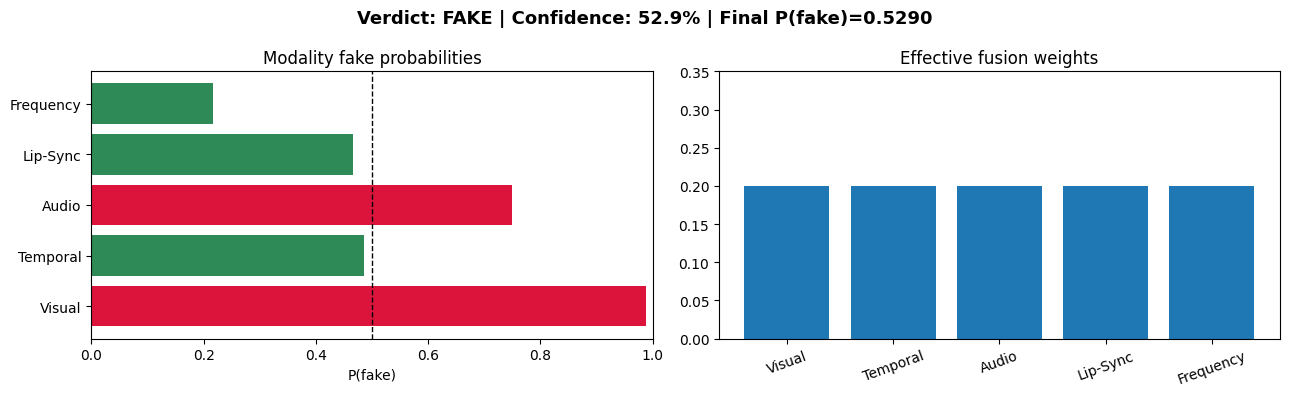

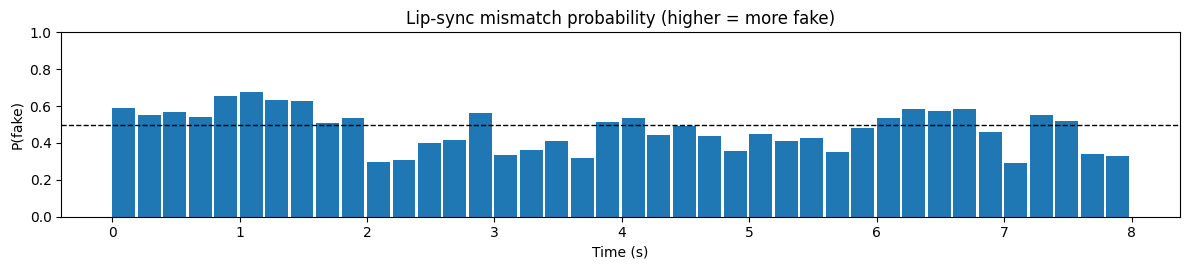

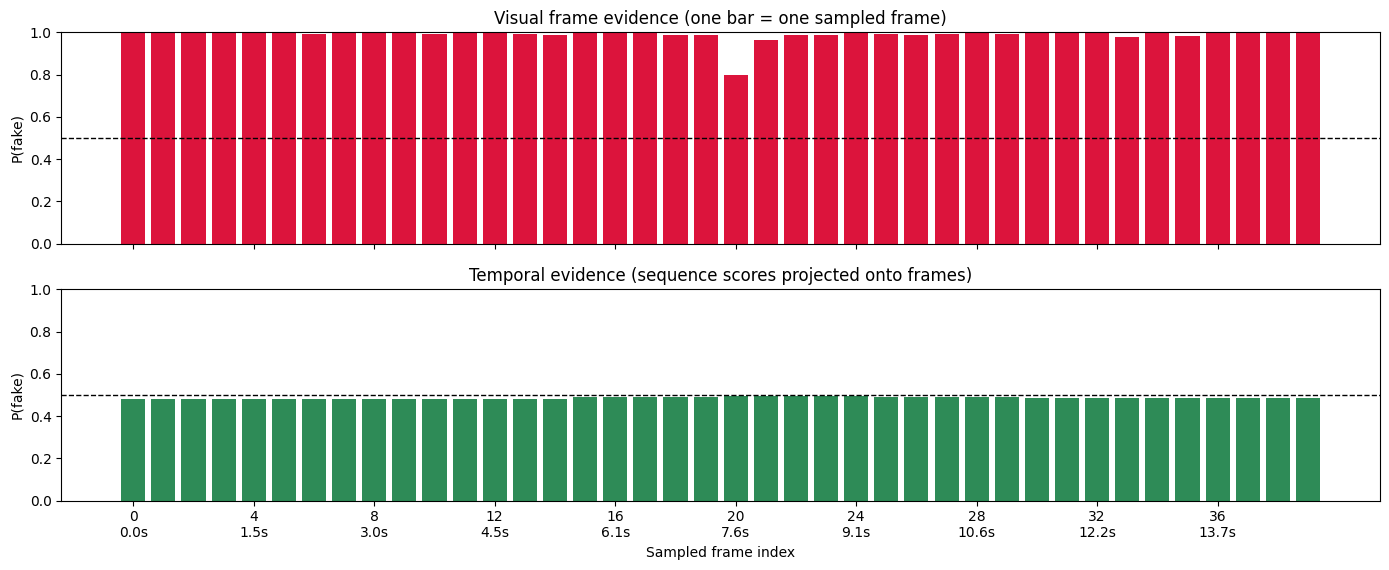

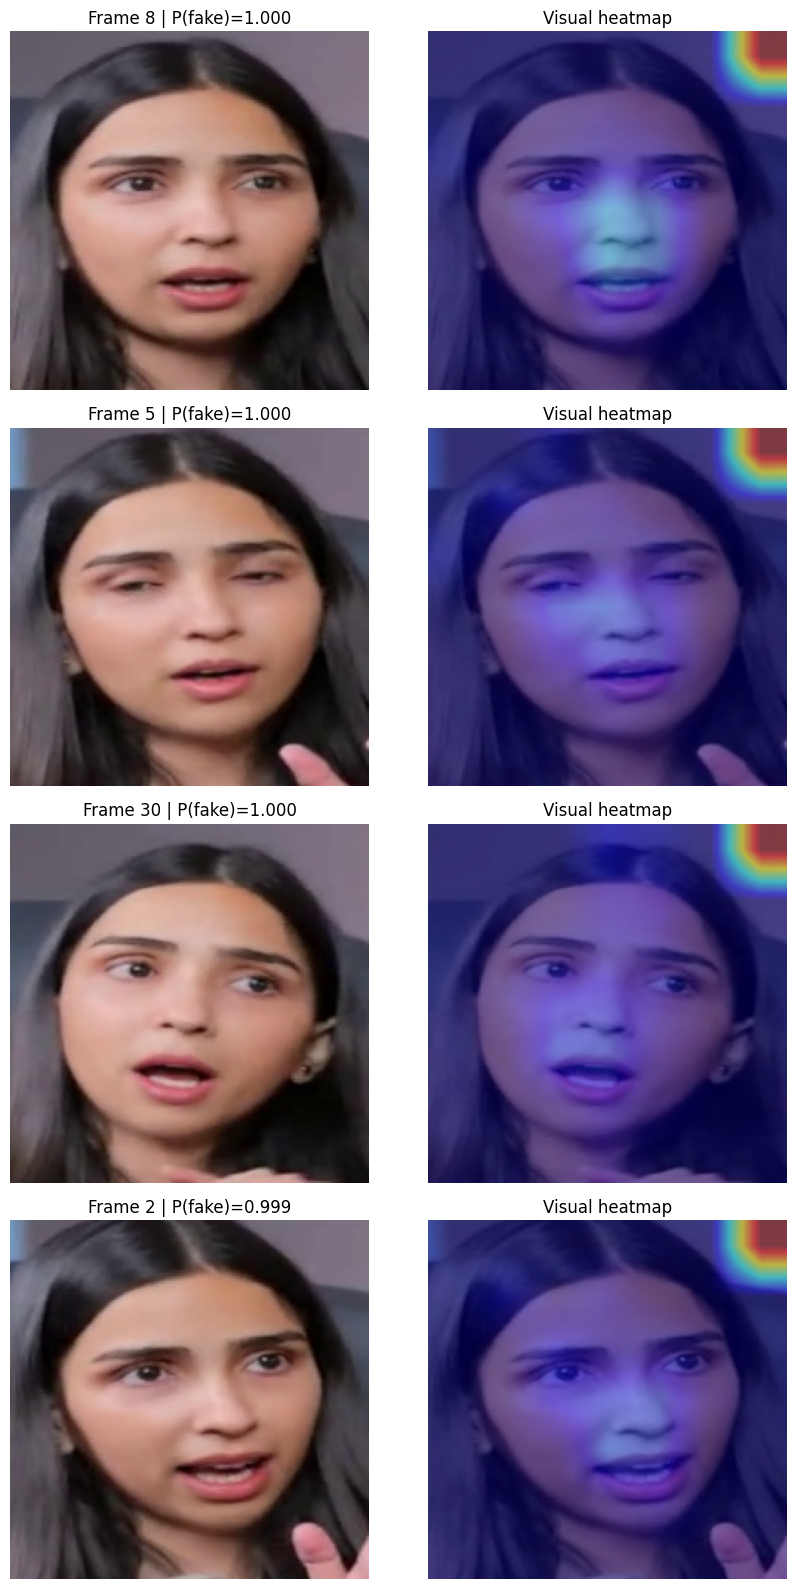


Saved outputs to: /content/drive/MyDrive/deepfake-project/outputs/final_demo


In [15]:
# Cell 10 — Choose video + run demo
INPUT_MODE = "upload"   # options: "upload" or "drive"
DRIVE_VIDEO_PATH = "/content/drive/MyDrive/deepfake-project/data/demo/test_video.mp4"

import os, shutil

def get_video_path(input_mode="upload", drive_video_path=None):
    input_mode = str(input_mode).strip().lower()
    if input_mode == "upload":
        from google.colab import files
        print("Choose a video file (.mp4 / .avi / .mov / .mkv) from your computer:")
        uploaded = files.upload()
        if len(uploaded) == 0:
            raise ValueError("No file was uploaded. Please re-run the cell and choose a video file.")
        filename = list(uploaded.keys())[0]
        local_path = os.path.abspath(filename)
        print(f"✅ Uploaded: {local_path}")
        return local_path

    if input_mode == "drive":
        if not drive_video_path:
            raise ValueError("DRIVE_VIDEO_PATH is empty. Please set a valid Google Drive video path.")
        if not os.path.exists(drive_video_path):
            raise FileNotFoundError(f"Drive video not found: {drive_video_path}")
        print(f"✅ Using Drive video: {drive_video_path}")
        return drive_video_path

    raise ValueError("INPUT_MODE must be either 'upload' or 'drive'.")

VIDEO_PATH = get_video_path(INPUT_MODE, DRIVE_VIDEO_PATH)
result, report, one_line_conclusion = analyze_video(VIDEO_PATH)

print(report)
print("\nONE-LINE CONCLUSION:")
print(one_line_conclusion)

show_results(result)
show_lipsync_timeline(result)
show_visual_temporal_evidence(result)
show_visual_heatmaps(result)

print("\nSaved outputs to:", OUTPUT_DIR)

## Optional extra cell
Run the next cell if you want to print just the one-line conclusion separately.

In [16]:
seq_probs = result.get("extra", {}).get("temporal_seq_probs", [])

print("Temporal seq_probs (first 10):", seq_probs[:10])
print("Min:", min(seq_probs) if seq_probs else None)
print("Max:", max(seq_probs) if seq_probs else None)
print("Mean:", sum(seq_probs)/len(seq_probs) if seq_probs else None)

Temporal seq_probs (first 10): [0.481, 0.4812, 0.4818, 0.4952, 0.4931, 0.4828, 0.4845]
Min: 0.481
Max: 0.4952
Mean: 0.48565714285714284


In [17]:
visual_probs = result["extra"]["visual_frame_probs"]

print("Number of visual frames:", len(visual_probs))
print("Min:", min(visual_probs))
print("Max:", max(visual_probs))
print("Mean:", sum(visual_probs) / len(visual_probs))
print("All values:")
for i, p in enumerate(visual_probs):
    print(f"Frame {i}: {p:.6f}")

Number of visual frames: 40
Min: 0.7977
Max: 0.9996
Mean: 0.9888475
All values:
Frame 0: 0.997700
Frame 1: 0.996700
Frame 2: 0.999400
Frame 3: 0.999100
Frame 4: 0.999000
Frame 5: 0.999600
Frame 6: 0.990600
Frame 7: 0.996600
Frame 8: 0.999600
Frame 9: 0.996800
Frame 10: 0.994100
Frame 11: 0.997600
Frame 12: 0.999300
Frame 13: 0.994000
Frame 14: 0.989600
Frame 15: 0.995100
Frame 16: 0.996800
Frame 17: 0.994600
Frame 18: 0.989000
Frame 19: 0.989500
Frame 20: 0.797700
Frame 21: 0.965400
Frame 22: 0.988300
Frame 23: 0.988700
Frame 24: 0.995600
Frame 25: 0.994000
Frame 26: 0.986200
Frame 27: 0.993100
Frame 28: 0.995600
Frame 29: 0.993000
Frame 30: 0.999500
Frame 31: 0.999300
Frame 32: 0.998500
Frame 33: 0.978700
Frame 34: 0.997800
Frame 35: 0.981000
Frame 36: 0.998600
Frame 37: 0.995500
Frame 38: 0.994600
Frame 39: 0.998100


In [18]:
# Cell 11 — Print only the one-line conclusion
try:
    print(one_line_conclusion)
except NameError:
    print("Run the previous demo cell first.")

Likely fake (52.9% confidence): visual suspicion peaks at sampled frames 5 (1.90s), 8 (3.03s), 30 (11.40s), and temporal inconsistency peaks at sampled frames 20 (7.60s), 21 (7.97s), 22 (8.37s).
